<a href="https://colab.research.google.com/github/maryamjz224/-README_Lab4.md/blob/main/Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

##Load data


In [17]:

import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("ihelon/coffee-sales")


print(path)

Using Colab cache for faster access to the 'coffee-sales' dataset.
/kaggle/input/coffee-sales


In [22]:
csv_path = os.path.join(path, "index_1.csv")
df = pd.read_csv(csv_path, encoding="latin-1")

In [23]:
df.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


##cheak data type

In [32]:
df.dtypes

,0
date,datetime64[ns]
datetime,datetime64[ns]
cash_type,object
card,object
money,float64
coffee_name,object


In [25]:
df['date'] = pd.to_datetime(df['date'])
df['datetime'] = pd.to_datetime(df['datetime'])

In [26]:
df.dtypes

,0
date,datetime64[ns]
datetime,datetime64[ns]
cash_type,object
card,object
money,float64
coffee_name,object


##Missing vlues

In [27]:
df.isna().sum()

,0
date,0
datetime,0
cash_type,0
card,89
money,0
coffee_name,0


In [28]:
df2 = df.copy()
df2.loc[0:5, 'money'] = np.nan


In [29]:
df2.isna().sum()

,0
date,0
datetime,0
cash_type,0
card,89
money,6
coffee_name,0


In [30]:
df2.head(10)

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,NaN,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,NaN,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,NaN,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,NaN,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,NaN,Latte
5,2024-03-01,2024-03-01 15:39:47.726,card,ANON-0000-0000-0005,NaN,Americano with Milk
6,2024-03-01,2024-03-01 16:19:02.756,card,ANON-0000-0000-0006,38.7,Hot Chocolate
7,2024-03-01,2024-03-01 18:39:03.580,card,ANON-0000-0000-0007,33.8,Americano with Milk
8,2024-03-01,2024-03-01 19:22:01.762,card,ANON-0000-0000-0008,38.7,Cocoa
9,2024-03-01,2024-03-01 19:23:15.887,card,ANON-0000-0000-0008,33.8,Americano with Milk


##Handling Missing Values
using remove records because the 89 is small relative to the total dataset size

In [31]:
df_remove = df2.dropna(subset=['money'])

In [ ]:
print('df with NaN: ', df2.shape)
print('df without NaN: ', df_remove.shape)

In [33]:
df_remove.isna().sum()


,0
date,0
datetime,0
cash_type,0
card,89
money,0
coffee_name,0


##Outliers

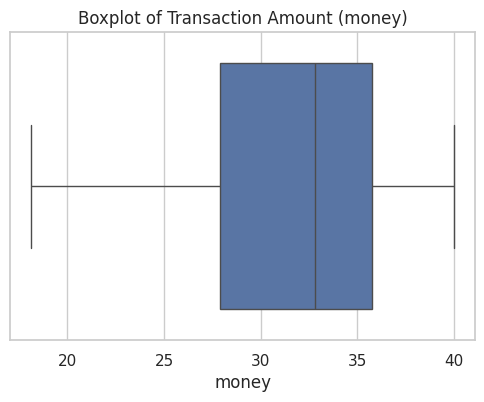

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['money'])
plt.title('Boxplot of Transaction Amount (money)')
plt.show()


###IQR

In [35]:
Q1 = df['money'].quantile(0.25)
Q3 = df['money'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower}, Upper bound: {upper}")

outliers = df[(df['money'] < lower) | (df['money'] > upper)]
print(f"\nNumber of outliers: {len(outliers)}")
outliers.head(15)


Q1: 27.92, Q3: 35.76, IQR: 7.839999999999996
Lower bound: 16.160000000000007, Upper bound: 47.519999999999996

Number of outliers: 0


,date,datetime,cash_type,card,money,coffee_name


Delete Outliers

In [37]:
df_no_outliers = df[(df['money'] >= lower) & (df['money'] <= upper)]

print('df with outliers: ', df.shape)
print('df without outliers: ', df_no_outliers.shape)


df with outliers:  (3636, 6)
df without outliers:  (3636, 6)


###Data normaization

In [38]:
df[['money']].describe()

,money
count,3636.000000
mean,31.746859
std,4.919926
min,18.120000
25%,27.920000
50%,32.820000
75%,35.760000
max,40.000000


In [39]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['money']].copy()

df_scaled[['money']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,money
0,0.940585
1,0.940585
2,0.940585
3,0.492687
4,0.940585


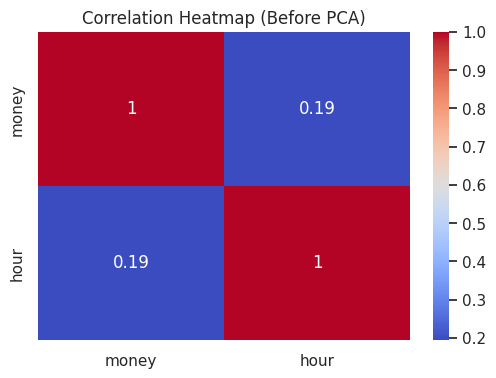

In [40]:
df_standardized2 = df.copy()
df_standardized2['hour'] = df_standardized2['datetime'].dt.hour

from sklearn.preprocessing import StandardScaler
scaler2 = StandardScaler()
df_standardized2[['money', 'hour']] = scaler2.fit_transform(df_standardized2[['money', 'hour']])

plt.figure(figsize=(6, 4))
sns.heatmap(df_standardized2[['money', 'hour']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Before PCA)')
plt.show()

In [41]:
from sklearn.decomposition import PCA

X = df_standardized2[['money', 'hour']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)


Explained Variance Ratio: [0.59738495 0.40261505]


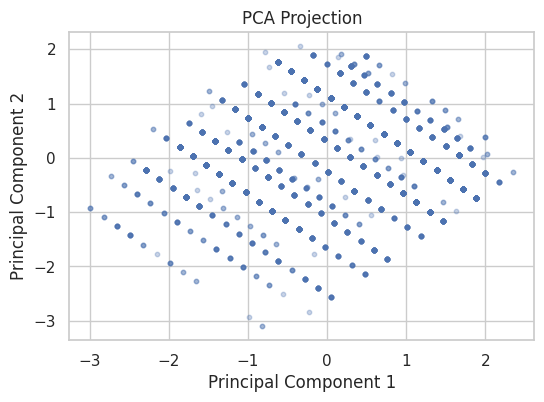

In [42]:
plt.figure(figsize=(6, 4))
plt.scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.3, s=10)
plt.title('PCA Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()